In [1]:
from cobwood.gfpmx import GFPMX

# Equations only required for debugging
from cobwood.gfpmx_equations import world_price_indround
from cobwood.gfpmx_equations import world_price

# Introduction

The purpose of this notebook is to reproduce estimations from the GFPMX model, using the spreadsheet data available from https://buongiorno.russell.wisc.edu/gfpm/.



Before using this object, the Excel file needs to be exported to csv files with:

      >>> from cobwood.gfpmx_spreadsheet_to_csv import gfpmx_spreadsheet_to_csv
      >>> gfpmx_spreadsheet_to_csv("~/large_models/GFPMX-8-6-2021.xlsx")


## Load data


In [2]:
gfpmxb2021 = GFPMX(scenario="base_2021", rerun=True)

Load input data from /home/paul/repos/cobwood_data/gfpmx_input/gfpmx_base2021 and reset time series to a base year 2021 before simulation start.


# Run


In [3]:
gfpmxb2021.run()

Running base_2021
Computing: 2070


# Destat and plots



## Plot consumption, import, export and production



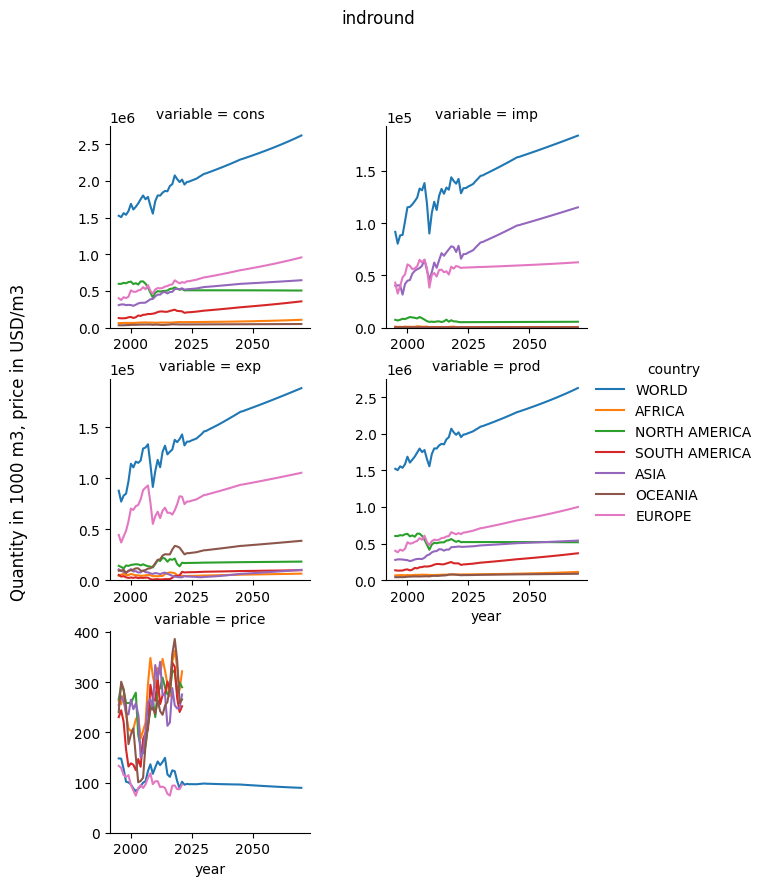

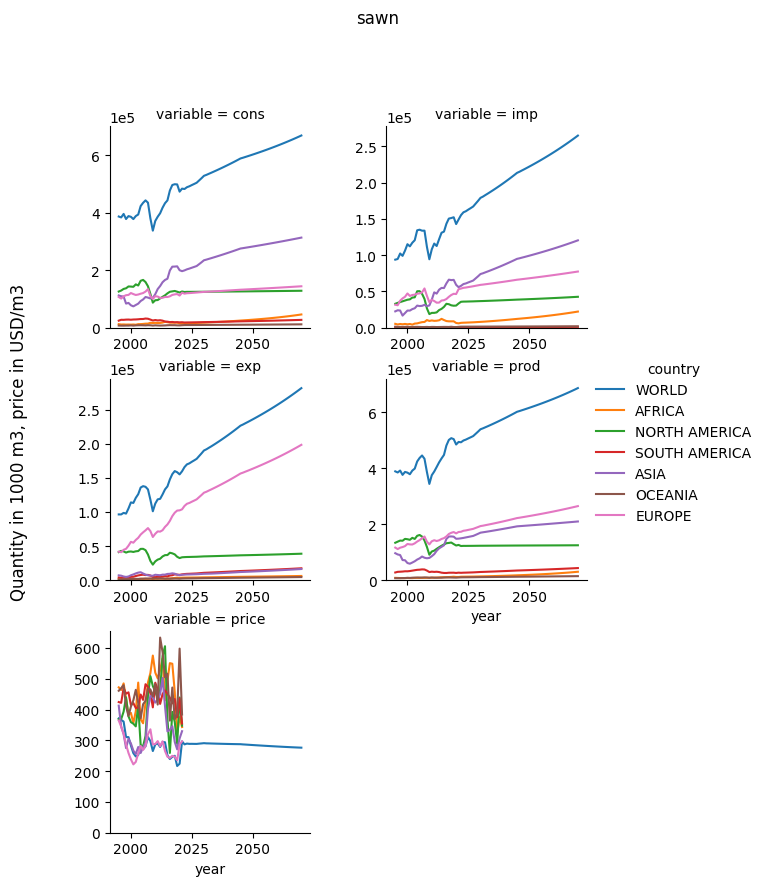

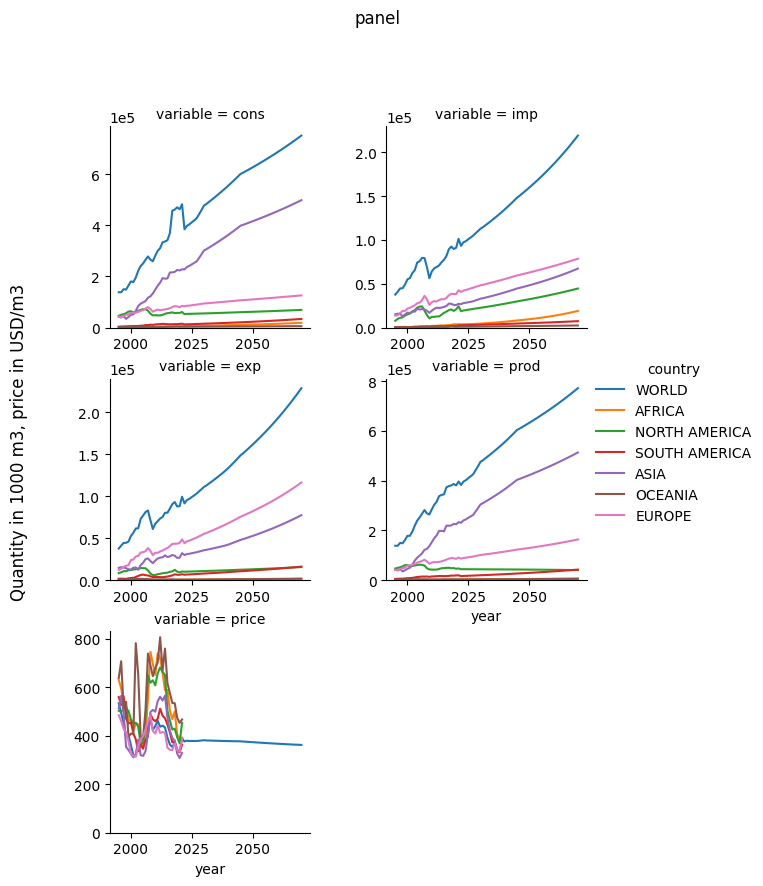

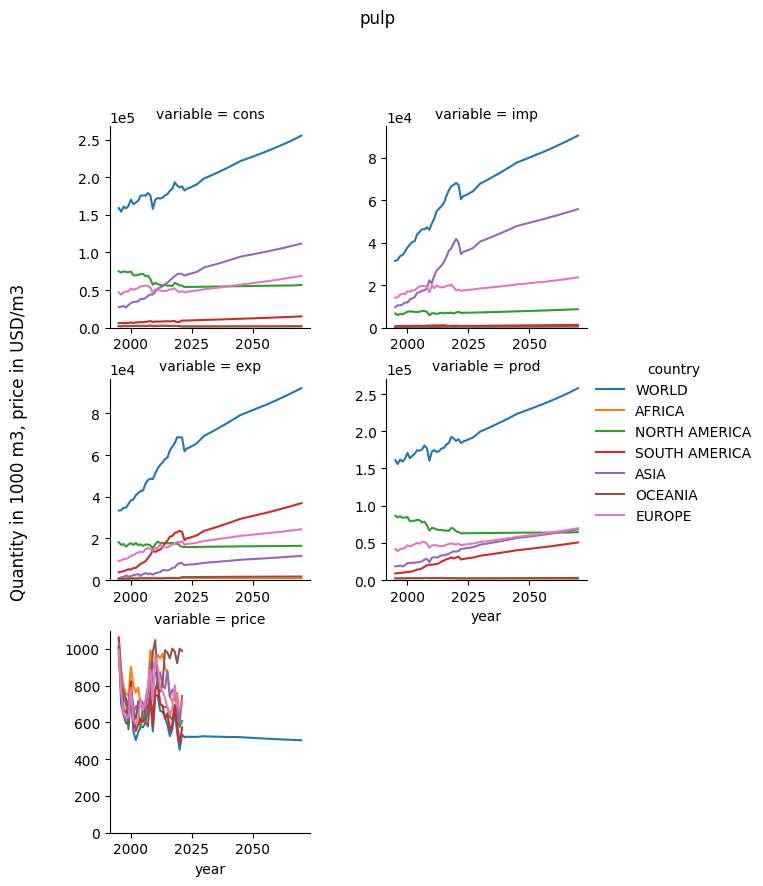

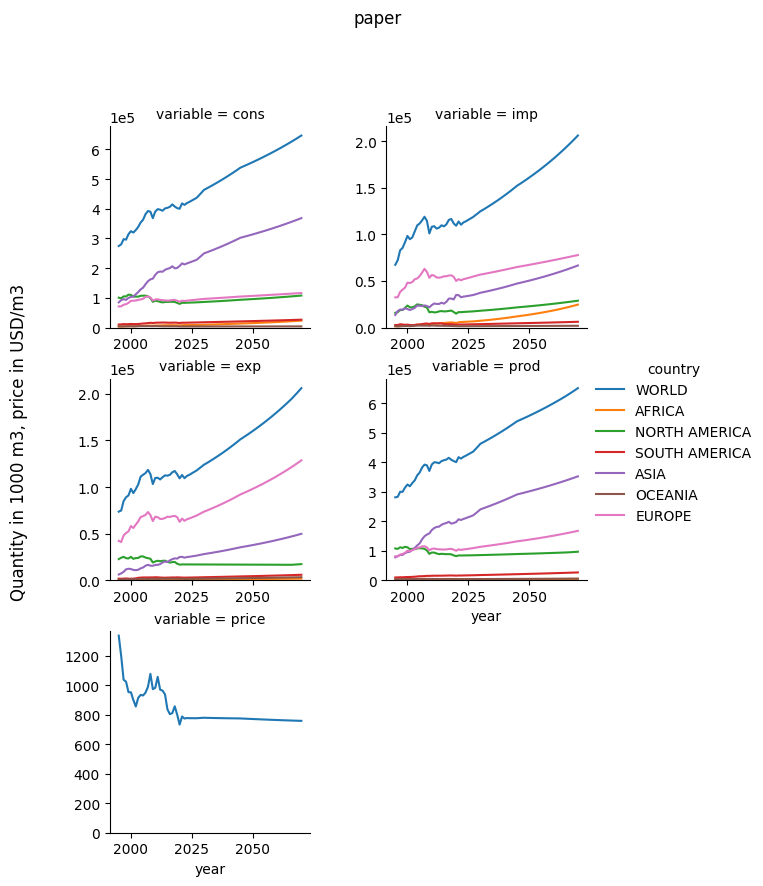

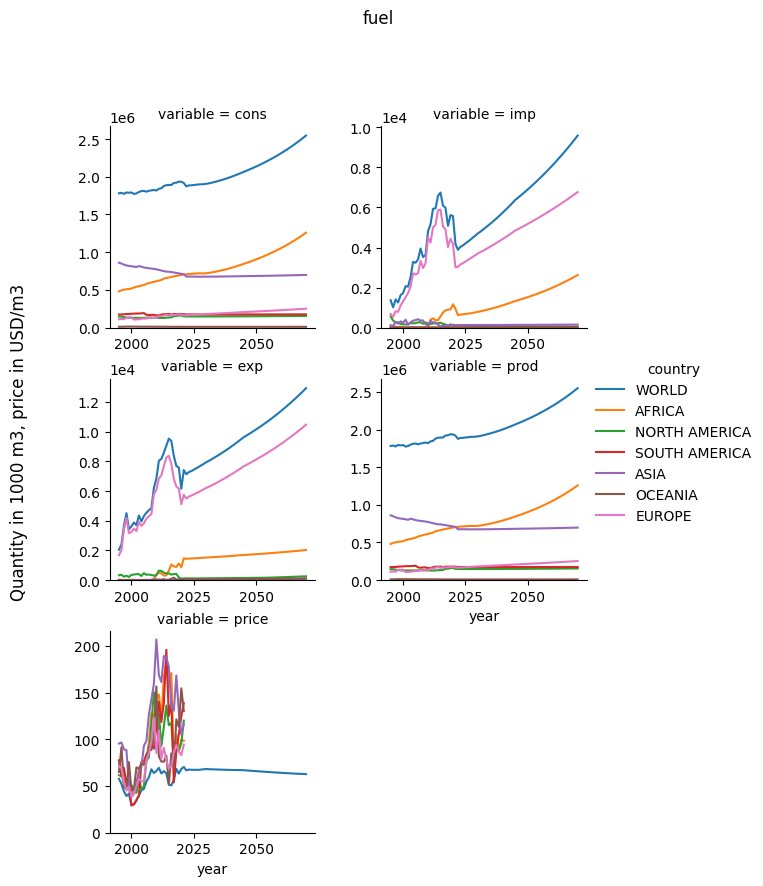

In [9]:
for product in ["indround", "sawn", "panel", "pulp", "paper", "fuel"]:
    gfpmxb2021.facet_plot_by_var(product)

## Plot forest area and stock

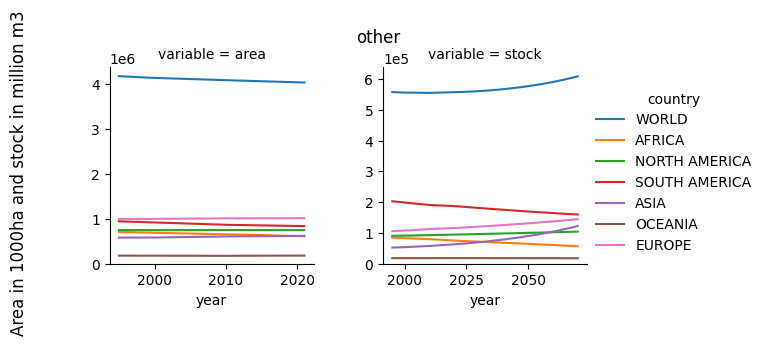

In [14]:
gfpmxb2021.facet_plot_by_var("other", variables=["area", "stock"], ylabel="Area in 1000ha and stock in million m3")

## Table of consumption and other values

In [13]:
da_vars = ["cons", "imp", "exp", "prod", "price"]
ds = gfpmxb2021.sawn
df = ds.loc[{"country": ~ds.c}][da_vars].to_dataframe()
df = df.reset_index().melt(id_vars=["country", "year"])
df.query("year==2023") 

,country,year,variable,value
28,WORLD,2023,cons,488904.109281
105,AFRICA,2023,cons,15330.509192
182,NORTH AMERICA,2023,cons,124458.215697
259,SOUTH AMERICA,2023,cons,17855.195862
336,ASIA,2023,cons,202831.987943
413,OCEANIA,2023,cons,8812.196112
490,EUROPE,2023,cons,119616.004475
567,WORLD,2023,imp,159106.781867
644,AFRICA,2023,imp,6719.241506
721,NORTH AMERICA,2023,imp,35838.200470


## EU countries only

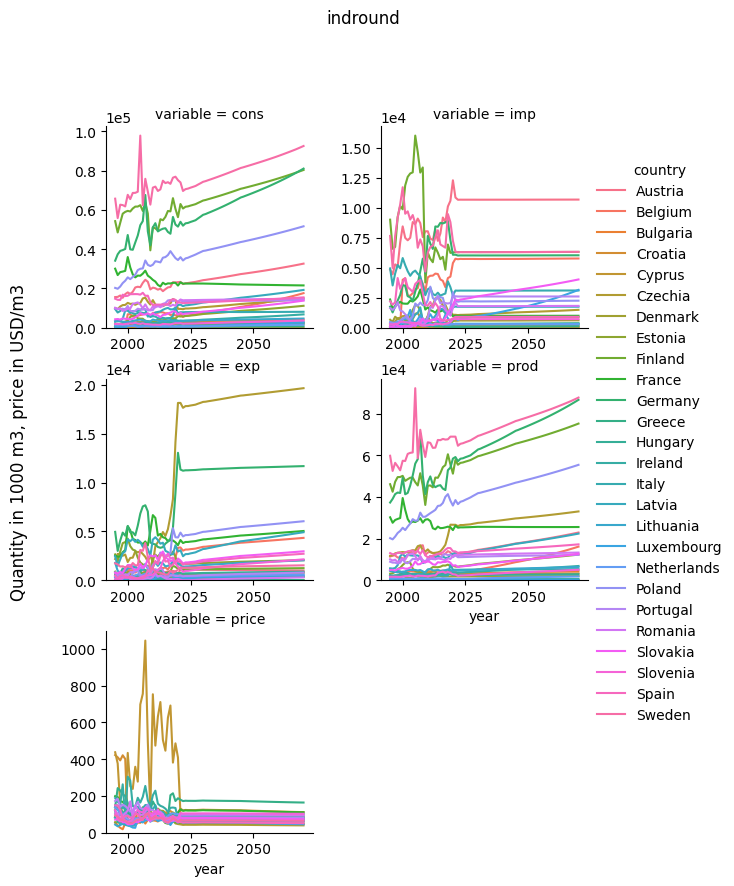

In [20]:
# EU27 member states (after Brexit)
# Note: Malta is not in the GFPMX dataset
eu27_countries = [
    "Austria",
    "Belgium",
    "Bulgaria",
    "Croatia",
    "Cyprus",
    "Czechia",
    "Denmark",
    "Estonia",
    "Finland",
    "France",
    "Germany",
    "Greece",
    "Hungary",
    "Ireland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    # "Malta",  # Not in the dataset
    "Netherlands",
    "Poland",
    "Portugal",
    "Romania",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden"
]

# Plot industrial roundwood for EU27 countries
gfpmxb2021.facet_plot_by_var("indround", countries=eu27_countries)